## **Задание 1. Составить и записать математическую модель задачи.**



Обозначим $x_1, x_2$ — объемы выпуска продукции 1 и 2 вида. 
Целевая функция (себестоимость одной единицы продукции):
$$F(x) = \frac{2.4x_1 + 1.2x_2}{x_1 + x_2} \rightarrow \min$$

Ограничения:
$$x_1 + x_2 = 175$$
$$x_1 \ge 1$$
$$x_2 \ge 1$$

## **Задание 2. Решить задачу методом обобщенного приведенного градиента (ОПГ) (в Python аналог — SLSQP).**

In [2]:
import numpy as np
from scipy.optimize import minimize, linprog
import matplotlib.pyplot as plt


In [14]:
def f(x):
    return (2.4 * x[0] + 1.2 * x[1]) / (x[0] + x[1])

c1 =[{'type': 'eq', 'fun': lambda x: x[0] + x[1] - 175}]
b = [(1, None), (1, None)]
xi = [1, 1]

r1 = minimize(f, xi, method='SLSQP', bounds=b, constraints=c1)
print(r1.x)
print(r1.fun)

[  1. 174.]
1.2068571428571435


## **Задание 3. Переход к новым переменным и решение симплекс-методом.**


Применим замену Чарнса-Купера:
$y_0 = \frac{1}{x_1 + x_2}$, $y_1 = x_1 y_0$, $y_2 = x_2 y_0$.
Целевая функция: $2.4y_1 + 1.2y_2 \rightarrow \min$

Ограничения:
1) $y_1 + y_2 = 1$ (так как $y_1+y_2 = \frac{x_1+x_2}{x_1+x_2}$)
2) $y_1 + y_2 - 175y_0 = 0$ (из $x_1+x_2=175$)
3) $-y_1 + y_0 \le 0$ (из $x_1 \ge 1$)
4) $-y_2 + y_0 \le 0$ (из $x_2 \ge 1$)

In [4]:
o =[2.4, 1.2, 0]
ae = [[1, 1, 0],[1, 1, -175]]
be = [1, 0]
au = [[-1, 0, 1], [0, -1, 1]]
bu = [0, 0]
bd = [(0, None), (0, None), (0, None)]

r2 = linprog(o, A_ub=au, b_ub=bu, A_eq=ae, b_eq=be, bounds=bd, method='highs')
print(r2.x)
print(r2.fun)

[0.00571429 0.99428571 0.00571429]
1.2068571428571429


## **Задание 4. Обратная замена переменных.**


In [5]:
y1, y2, y0 = r2.x
x1 = y1 / y0
x2 = y2 / y0

print(np.round([x1, x2], 4))
print(np.allclose(r1.x, [x1, x2]))

[  1. 174.]
True


## **Задание 5. Графический метод.**

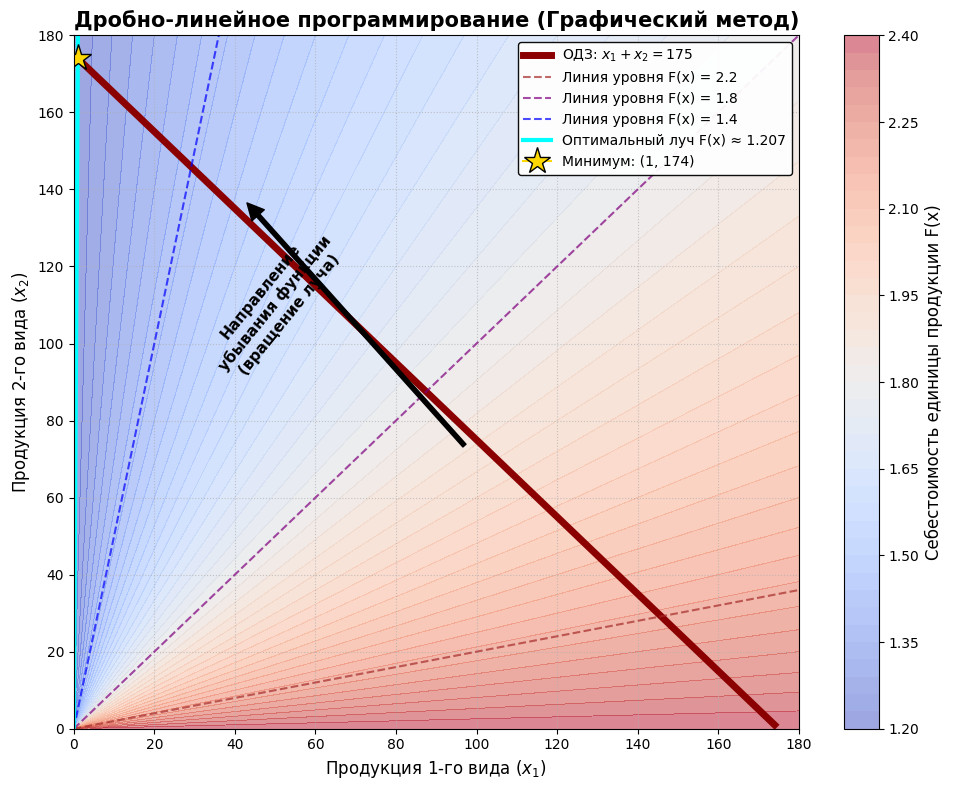

In [ ]:
plt.figure(figsize=(10, 8))

x1_mesh = np.linspace(0.1, 180, 400)
x2_mesh = np.linspace(0.1, 180, 400)
X1, X2 = np.meshgrid(x1_mesh, x2_mesh)
Z = (2.4 * X1 + 1.2 * X2) / (X1 + X2)

# Рисуем градиент
contour = plt.contourf(X1, X2, Z, levels=40, cmap='coolwarm', alpha=0.5)
cbar = plt.colorbar(contour)
cbar.set_label('Себестоимость единицы продукции F(x)', fontsize=12)

# 2. ОДЗ (Допустимое множество)
# У нас жесткое условие x1 + x2 = 175, при x1 >= 1, x2 >= 1. 
x1_line = np.linspace(1, 174, 200)
x2_line = 175 - x1_line

# Рисуем саму линию ограничений
plt.plot(x1_line, x2_line, color='darkred', linewidth=5, label=r'ОДЗ: $x_1 + x_2 = 175$')

# 3. ЛИНИИ УРОВНЯ (Лучи дробно-линейной функции)
# Если F(x) = c, то x2 = x1 * (c - 2.4) / (1.2 - c)
c_values =[2.2, 1.8, 1.4]  # Разные значения себестоимости
colors = ['brown', 'purple', 'blue']
for c, col in zip(c_values, colors):
    slope = (c - 2.4) / (1.2 - c)
    plt.plot([0, 180],[0, 180 * slope], color=col, linestyle='--', alpha=0.7,
             label=f'Линия уровня F(x) = {c}')

# 4. ОПТИМАЛЬНАЯ ТОЧКА
x1_opt, x2_opt = 1, 174
f_opt = (2.4 * x1_opt + 1.2 * x2_opt) / (x1_opt + x2_opt)

# Луч, проходящий через оптимум
slope_opt = (f_opt - 2.4) / (1.2 - f_opt)
plt.plot([0, 180],[0, 180 * slope_opt], color='cyan', linestyle='-', linewidth=3,
         label=f'Оптимальный луч F(x) ≈ {f_opt:.3f}')

# Звезда в точке минимума
plt.plot(x1_opt, x2_opt, marker='*', markersize=20, color='gold', 
         markeredgecolor='black', label='Минимум: (1, 174)')

# 5. НАПРАВЛЕНИЕ МИНИМИЗАЦИИ (Вращение луча)
plt.annotate('', xy=(40, 140), xytext=(100, 70),
             arrowprops=dict(facecolor='black', shrink=0.05, width=3, headwidth=12),
             fontsize=12)
plt.text(50, 90, 'Направление\nубывания функции\n(вращение луча)', 
         fontsize=11, rotation=51, ha='center', fontweight='bold')

# Оформление осей и графика
plt.xlim(0, 180)
plt.ylim(0, 180)
plt.xlabel('Продукция 1-го вида ($x_1$)', fontsize=12)
plt.ylabel('Продукция 2-го вида ($x_2$)', fontsize=12)
plt.title('Дробно-линейное программирование (Графический метод)', fontsize=15, fontweight='bold')

# Красивая легенда
plt.legend(loc='upper right', framealpha=0.95, edgecolor='black')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## **Задание 6 (*). Изменение условий на ограничения по оборудованию.**



Введем произвольную систему ограничений:

$2x_1 + x_2 \le 100$

$x_1 + 2x_2 \ge 20$

$x_1 + x_2 \le 80$

$x_1 \ge 1, x_2 \ge 1$

Оптимальный план: x1 = 1.00, x2 = 79.00
Минимальная себестоимость: 1.2150


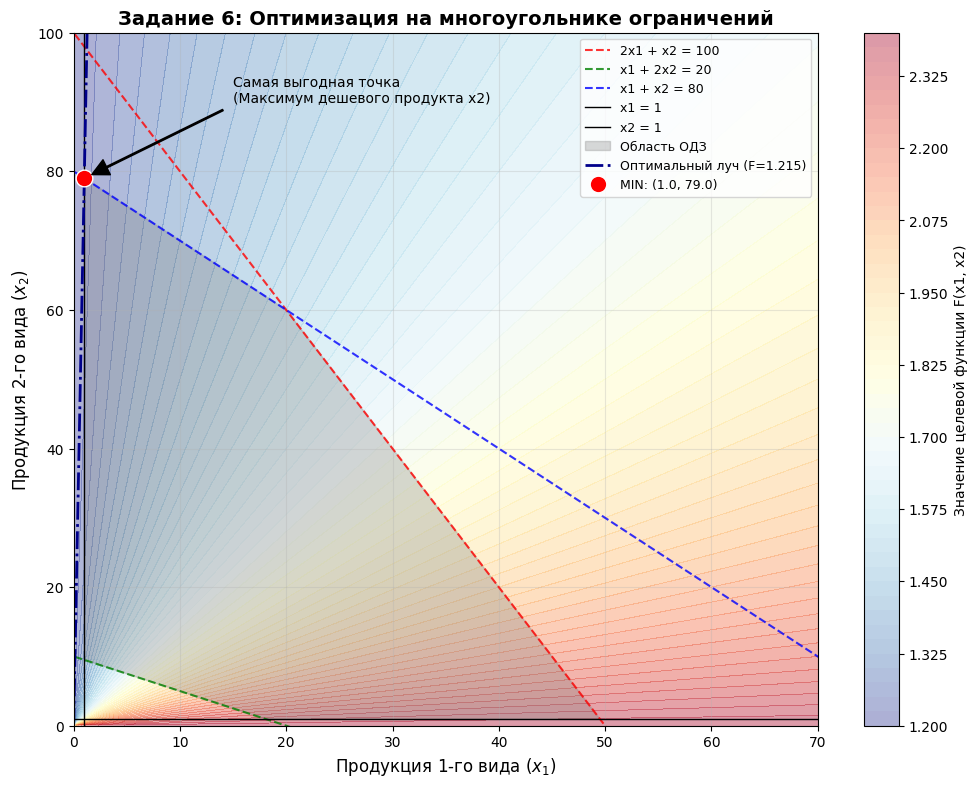

In [18]:
# Границы переменных
bounds = [(1, None), (1, None)]

# Система ограничений (переводим в формат g(x) >= 0)
cons = [
    {'type': 'ineq', 'fun': lambda x: 100 - (2 * x[0] + x[1])}, # 2x1 + x2 <= 100
    {'type': 'ineq', 'fun': lambda x: (x[0] + 2 * x[1]) - 20},  # x1 + 2x2 >= 20
    {'type': 'ineq', 'fun': lambda x: 80 - (x[0] + x[1])}      # x1 + x2 <= 80
]

xi_fixed = [10, 10] 

# Решение
res = minimize(f, xi_fixed, method='SLSQP', bounds=bounds, constraints=cons)
x_opt, y_opt = res.x
f_min = res.fun

print(f"Оптимальный план: x1 = {x_opt:.2f}, x2 = {y_opt:.2f}")
print(f"Минимальная себестоимость: {f_min:.4f}")

# 2. ПОСТРОЕНИЕ КРУТОГО ГРАФИКА
plt.figure(figsize=(12, 9))

# Сетка для тепловой карты
x_range = np.linspace(0.1, 100, 500)
y_range = np.linspace(0.1, 100, 500)
X, Y = np.meshgrid(x_range, y_range)
Z = (2.4 * X + 1.2 * Y) / (X + Y)

# Отрисовка цветовых зон (где дешевле - синее, где дороже - красное)
cp = plt.contourf(X, Y, Z, levels=50, cmap='RdYlBu_r', alpha=0.4)
plt.colorbar(cp).set_label('Значение целевой функции F(x1, x2)')

# Линии ограничений
plt.plot(x_range, 100 - 2*x_range, 'r--', label='2x1 + x2 = 100', alpha=0.8)
plt.plot(x_range, (20 - x_range)/2, 'g--', label='x1 + 2x2 = 20', alpha=0.8)
plt.plot(x_range, 80 - x_range, 'b--', label='x1 + x2 = 80', alpha=0.8)
plt.axvline(1, color='black', lw=1, label='x1 = 1')
plt.axhline(1, color='black', lw=1, label='x2 = 1')

# Заливка области допустимых решений (ОДЗ)
# Вершины многоугольника (найдены пересечением линий)
path_x = [1, 1, 20, 49.5, 18, 1]
path_y = [9.5, 79, 60, 1, 1, 9.5]
plt.fill(path_x, path_y, color='gray', alpha=0.3, label='Область ОДЗ')

# Линии уровня (вращающиеся лучи)
# Нарисуем луч, проходящий через наше найденное решение
plt.plot([0, 1.5], [0, 1.5 * (y_opt/x_opt)], color='darkblue', lw=2, linestyle='-.', 
         label=f'Оптимальный луч (F={f_min:.3f})')

# Отметка решения
plt.plot(x_opt, y_opt, 'ro', markersize=12, markeredgecolor='white', 
         label=f'MIN: ({x_opt:.1f}, {y_opt:.1f})')

# Аннотация
plt.annotate('Самая выгодная точка\n(Максимум дешевого продукта x2)', 
             xy=(x_opt, y_opt), xytext=(15, 90),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

# Настройка осей
plt.xlim(0, 70)
plt.ylim(0, 100)
plt.xlabel('Продукция 1-го вида ($x_1$)', fontsize=12)
plt.ylabel('Продукция 2-го вида ($x_2$)', fontsize=12)
plt.title('Задание 6: Оптимизация на многоугольнике ограничений', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)

plt.show()